### Exercice 2

In [18]:
# All imports 
import seaborn as sns
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import least_squares

In [19]:
# step 1 

# load dataset
df = pd.read_csv("option20230201_20230228.csv")

print("Initial rows:", len(df))

# keep calls only 
df = df[df["cp_flag"] == "C"].copy()
print("After keeping calls:", len(df))

# convert date columns
df["date"] = pd.to_datetime(df["date"])
df["exdate"] = pd.to_datetime(df["exdate"])

# rescale strike 
df["strike"] = df["strike_price"] / 1000

# construct midquote 
df["V"] = (df["best_bid"] + df["best_offer"]) / 2

# remove missing implied volatility cells 
df = df.dropna(subset=["impl_volatility"])
df= df[(df["impl_volatility"]>=0)]
print("After removing missing and non positive IV:", len(df))

# usefull for reporting 
final_columns = [
    col for col in df.columns
    if col in ["date", "exdate", "symbol", "strike", "V", "impl_volatility", "delta"]
]
df = df[final_columns].copy()
print("Number of unique trading dates:", df["date"].nunique())
print("Number of unique expiries:", df["exdate"].nunique())
print("\nMissing rates:")
print(df[["V", "impl_volatility", "delta"]].isna().mean())
print("\nFinal columns kept:")
print(df.columns.tolist())

Initial rows: 175301
After keeping calls: 175301
After removing missing and non positive IV: 153728
Number of unique trading dates: 19
Number of unique expiries: 67

Missing rates:
V                  0.0
impl_volatility    0.0
delta              0.0
dtype: float64

Final columns kept:
['date', 'symbol', 'exdate', 'impl_volatility', 'delta', 'strike', 'V']


In [20]:
# step 2 

# sort so shifting will work correctly within each contract
df = df.sort_values(["symbol", "date"]).copy()

# compute one-day option change within each contract 
df["dV"] = df.groupby("symbol")["V"].diff(1)

# only keep observations where ΔV_t is defined 
before_rows = len(df)
df = df.dropna(subset=["dV"]).copy()
after_rows = len(df)

# report how many contracts remain 
contracts_before = df["symbol"].nunique() 

# usefull for reporting 
print(f"Rows before computing ΔV (sorted): {before_rows}")
print(f"Rows after keeping defined ΔV:      {after_rows}")
print(f"Number of contracts retained:       {contracts_before}")

# summary statistics of V_t and ΔV_t
summary_V = df["V"].describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99])
summary_dV = df["dV"].describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99])

print("\nSummary stats of V:")
print(summary_V)

print("\nSummary stats of ΔV:")
print(summary_dV)

Rows before computing ΔV (sorted): 153728
Rows after keeping defined ΔV:      141619
Number of contracts retained:       11593

Summary stats of V:
count    141619.000000
mean        424.438543
std         575.665037
min           0.025000
1%            0.025000
5%            0.075000
50%         199.800000
95%        1610.120000
99%        2721.941000
max        3993.700000
Name: V, dtype: float64

Summary stats of ΔV:
count    141619.000000
mean         -6.315655
std          27.128320
min        -170.300000
1%          -78.700000
5%          -48.150000
50%          -2.150000
95%          44.950000
99%          56.000000
max          70.200000
Name: dV, dtype: float64


Merge coverage: 100.00%

Summary statistics of S_t (from SPX data):
count      21.000000
mean     4068.892857
std        74.859994
min      3951.390000
25%      3991.050000
50%      4090.410000
75%      4136.130000
max      4179.760000
Name: S, dtype: float64

Summary statistics of ΔS_t (from SPX data):
count    20.000000
mean     -6.893000
std      38.249932
min     -81.750000
25%     -37.840000
50%      -8.805000
75%      14.467500
max      60.550000
Name: dS, dtype: float64


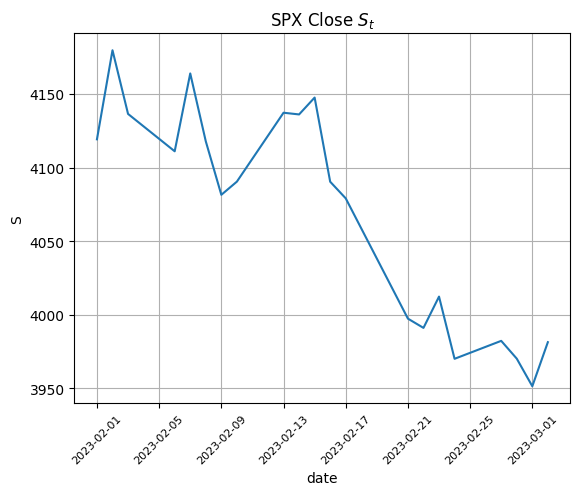

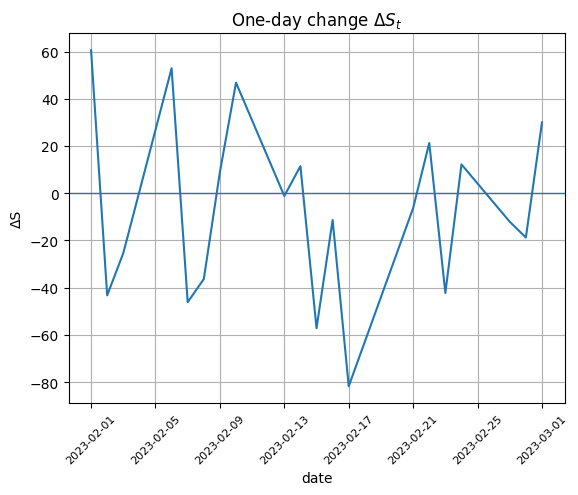

In [21]:
# step 3
def load_spx(start="2023-02-01", end="2023-03-02"):
    d1 = pd.Timestamp(start).strftime("%Y%m%d")
    d2 = pd.Timestamp(end).strftime("%Y%m%d")

    url = f"https://stooq.com/q/d/l/?s=^spx&d1={d1}&d2={d2}&i=d"
    spx = pd.read_csv(url)

    cols = {c.lower(): c for c in spx.columns}
    if "date" not in cols or "close" not in cols:
        raise ValueError(f"Stooq returned unexpected columns: {spx.columns.tolist()}")

    spx = spx.rename(columns={cols["date"]: "date", cols["close"]: "S"})
    spx["date"] = pd.to_datetime(spx["date"])
    spx = spx.sort_values("date").reset_index(drop=True)

    # compute one-day change
    spx["dS"] = spx["S"].shift(-1) - spx["S"]

    return spx

def plot_spx_and_dS(spx):
    plt.figure()
    plt.plot(spx["date"], spx["S"])
    plt.title("SPX Close $S_t$")
    plt.xlabel("date")
    plt.ylabel("S")
    plt.xticks(rotation=45, fontsize=8)
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(spx["date"], spx["dS"])
    plt.title("One-day change $\\Delta S_t$")
    plt.xlabel("date")
    plt.ylabel("ΔS")
    plt.axhline(0, linewidth=1)
    plt.xticks(rotation=45, fontsize=8)
    plt.grid(True)
    plt.show()

# run step 3
spx = load_spx(start="2023-02-01", end="2023-03-02")


#We merge
df = pd.merge(df, spx[["date", "S", "dS"]], on="date", how="left")
before_merge_rows = len(df)
df = df.dropna(subset=["S", "dS"]).copy()


coverage = len(df) / before_merge_rows
print(f"Merge coverage: {coverage:.2%}")

print("\nSummary statistics of S_t (from SPX data):")
print(spx["S"].describe())

print("\nSummary statistics of ΔS_t (from SPX data):")
print(spx["dS"].describe())

plot_spx_and_dS(spx)

In [22]:
# step 4
#Same code used for asingment 1

# option trading dates T^opt
df["date"] = pd.to_datetime(df["date"]).dt.normalize()
opt_dates = df["date"].drop_duplicates().sort_values()

# load Treasury yields
url = ("https://home.treasury.gov/resource-center/data-chart-center/interest-rates/daily-treasury-rate-archives/par-yield-curve-rates-2020-2023.csv")

tr = pd.read_csv(url)

tr["date"] = pd.to_datetime(tr["date"]).dt.normalize()
tr = tr.sort_values("date")

# only keep required tenors and map them to m in years
tenor_map = {
    "1 mo": 1/12,
    "2 mo": 2/12,
    "3 mo": 3/12,
    "6 mo": 6/12,
    "1 yr": 1,
    "2 yr": 2,
    "3 yr": 3,
    "5 yr": 5,
    "7 yr": 7,
    "10 yr": 10,
    "20 yr": 20,
    "30 yr": 30,
}

# check if treasury file uses different labels
missing = [c for c in tenor_map.keys() if c not in tr.columns]
if missing:
    raise ValueError(
        "Treasury file is missing expected tenor columns: "
        f"{missing}\nAvailable columns: {tr.columns.tolist()}"
    )

# keep date and required tenors
tr = tr[["date"] + list(tenor_map.keys())].copy()

# convert yields 
for c in tenor_map.keys():
    tr[c] = pd.to_numeric(tr[c], errors="coerce")

# rename columns to the maturity m (in years)
tr = tr.rename(columns=tenor_map)
tr = tr.set_index("date").sort_index()

# sort maturities in increasing order
tr = tr[sorted(tr.columns)]

# align to option dates 
tr_panel = tr.reindex(opt_dates)

# forward-fill
tr_panel = tr_panel.ffill()

# back-fill if needed at the very beginning
if tr_panel.isna().any(axis=None):
    tr_panel = tr_panel.bfill()

tr_panel = tr_panel / 100.0


# step 4b (from asign 1)

import numpy as np

def g1(tau, tau1):
    x = tau / tau1
    return (1 - np.exp(-x)) / x

def g2(tau, tau1):
    x = tau / tau1
    return g1(tau, tau1) - np.exp(-x)

def g3(tau, tau2):
    x = tau / tau2
    return (1 - np.exp(-x)) / x - np.exp(-x)

def nss_yield(tau, beta0, beta1, beta2, beta3, tau1, tau2):
    return (
        beta0
        + beta1 * g1(tau, tau1)
        + beta2 * g2(tau, tau1)
        + beta3 * g3(tau, tau2)
    )

In [23]:
# step 4c (from asign 1)
def build_X(maturities, tau1, tau2):
    maturities = np.array(maturities, dtype=float)
    X = np.column_stack([
        np.ones_like(maturities),
        g1(maturities, tau1),
        g2(maturities, tau1),
        g3(maturities, tau2),
    ])
    return X

def ols_beta(X, y):
    beta, residuals, rank, singular_values = np.linalg.lstsq(X, y, rcond=None)
    return beta

def sse(X, y, beta):
    resid = y - X @ beta
    return float(resid @ resid)

def fit_nss(yields_by_maturity, maturities, tau_grid):
    y = np.asarray(yields_by_maturity, dtype=float)
    best = {
        "tau1": None, "tau2": None, "beta": None, "sse": np.inf
    }

    for tau1 in tau_grid:
        for tau2 in tau_grid:
            if tau2 < tau1:   
                continue

            X = build_X(maturities, tau1, tau2)
            beta = ols_beta(X, y)
            val = sse(X, y, beta)

            if val < best["sse"]:
                best.update({"tau1": tau1, "tau2": tau2, "beta": beta, "sse": val})

    return best["tau1"], best["tau2"], best["beta"], best["sse"]

# maturities in years
mats = np.array(tr_panel.columns, dtype=float)

# yields observed at those maturities for each date
Y = tr_panel.to_numpy(dtype=float) 

tau_grid = np.array([0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0], dtype=float)

rows = []
for i, date in enumerate(tr_panel.index):
    tau1_hat, tau2_hat, beta_hat, sse_hat = fit_nss(
        yields_by_maturity=Y[i, :],
        maturities=mats,
        tau_grid=tau_grid
    )
    rows.append({
        "date": date,
        "tau1": tau1_hat,
        "tau2": tau2_hat,
        "beta0": beta_hat[0],
        "beta1": beta_hat[1],
        "beta2": beta_hat[2],
        "beta3": beta_hat[3],
        "sse": sse_hat,
    })

nss_params = pd.DataFrame(rows).set_index("date").sort_index()

# step 4d and 4e (from asign 1)

# ensure normalized dates
df["date"] = pd.to_datetime(df["date"]).dt.normalize()
df["exdate"] = pd.to_datetime(df["exdate"]).dt.normalize()

# Step 4d: tau in years, clamp lower bound 1/365
df["tau"] = (df["exdate"] - df["date"]).dt.days / 365.0
df["tau"] = df["tau"].clip(lower=1/365)

def fitted_yield(tau, beta0, beta1, beta2, beta3, tau1, tau2):
    return beta0 + beta1*g1(tau, tau1) + beta2*g2(tau, tau1) + beta3*g3(tau, tau2)

fitted = []
for row in df.itertuples():
    params = nss_params.loc[row.date]
    fitted.append(
        fitted_yield(row.tau,
                     params["beta0"], params["beta1"], params["beta2"], params["beta3"],
                     params["tau1"], params["tau2"])
    )

df["y_hat"] = fitted

# continuous zero rate
df["r"] = 2 * np.log1p(df["y_hat"] / 2)

# discount factor
df["P"] = np.exp(-df["r"] * df["tau"])

In [24]:
# Computing delta and epsilon_t using the Black-Scholes model

df["q"] = 0.0

df["F"] = df["S"] * np.exp((df["r"] - df["q"]) * df["tau"])

d1 = (np.log(df["S"] / df["strike"]) + (df["r"] - df["q"] + 0.5 * df["impl_volatility"]**2) * df["tau"]) / (df["impl_volatility"] * np.sqrt(df["tau"]))
df["delta_bs"] = np.exp(-df["q"] * df["tau"]) * norm.cdf(d1)

df["dS_hedge"] = df["dS"] + df["S"] * (np.exp(df["q"] * (1/252)) - 1) 

df["eps_bs"] = df["dV"] - df["delta_bs"] * df["dS_hedge"]

sse_bs = df["eps_bs"].dropna().pow(2).sum()
mse_bs = df["eps_bs"].dropna().pow(2).mean()

print(f"Summary stats of epsilon_t (Baseline BS):")
print(df["eps_bs"].describe())
print(f"\nBaseline SSE (before final filtering): {sse_bs}")

Summary stats of epsilon_t (Baseline BS):
count    141619.000000
mean          1.329964
std          39.499324
min        -164.011554
25%         -22.268707
50%          -0.412971
75%          20.653615
max         106.157950
Name: eps_bs, dtype: float64

Baseline SSE (before final filtering): 221202417.7051661


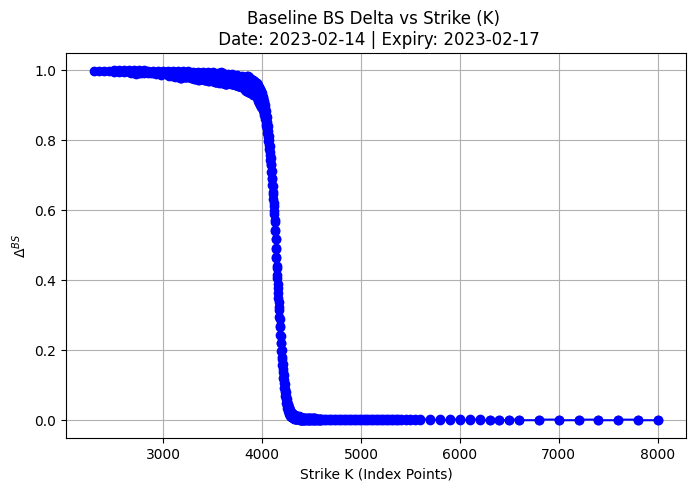


--- Volatility Misspecification Experiment ---
Shift:   -10%            -> SSE: 235,675,215
Shift:    -5%            -> SSE: 227,499,333
Shift:    +0% (Baseline) -> SSE: 221,202,418
Shift:    +5%            -> SSE: 216,391,087
Shift:   +10%            -> SSE: 212,736,210


In [25]:
sample_date = df['date'].dropna().iloc[0]
sample_slice = df[df['date'] == sample_date]

if not sample_slice.empty:
    sample_exdate = sample_slice['exdate'].dropna().iloc[0]
    slice_to_plot = sample_slice[sample_slice['exdate'] == sample_exdate].sort_values('strike')
    
    plt.figure(figsize=(8, 5))
    plt.plot(slice_to_plot['strike'], slice_to_plot['delta_bs'], marker='o', linestyle='-', color='b')
    plt.title(f"Baseline BS Delta vs Strike (K) \n Date: {sample_date.date()} | Expiry: {sample_exdate.date()}")
    plt.xlabel("Strike K (Index Points)")
    plt.ylabel(r"$\Delta^{BS}$")
    plt.grid(True)
    plt.show()


print("\n--- Volatility Misspecification Experiment ---")

sigma_shifts = [-0.10, -0.05, 0.0, 0.05, 0.10]

for shift in sigma_shifts:
    
    shifted_vol = np.maximum(df["impl_volatility"] + shift, 0.001)
    
    
    d1_shifted = (np.log(df["S"] / df["strike"]) + (df["r"] - df["q"] + 0.5 * shifted_vol**2) * df["tau"]) / (shifted_vol * np.sqrt(df["tau"]))
    delta_shifted = pd.Series(np.exp(-df["q"] * df["tau"]) * norm.cdf(d1_shifted), index=df.index)
    
    
    eps_shifted = df["dV"] - delta_shifted * df["dS_hedge"]
    sse_shifted = eps_shifted.dropna().pow(2).sum()
    
    
    if shift == 0.0:
        print(f"Shift: {shift*100:>+5.0f}% (Baseline) -> SSE: {sse_shifted:,.0f}")
    else:
        print(f"Shift: {shift*100:>+5.0f}%            -> SSE: {sse_shifted:,.0f}")

In [26]:
# Step 5

def sabr_implied_vol(F, K, tau, alpha, rho, nu):

    if np.abs(np.log(F / K)) < 1e-12:
        I1 = (rho * nu * alpha) / 4 + (2 - 3 * rho**2) / 24 * nu**2
        return alpha * (1 + tau* I1 )

    x = np.log(F / K)
    z = (nu / alpha) * x
    xi = np.sqrt(1 - 2 * rho * z + z**2)
    chi = np.log((xi + z - rho) / (1 - rho))

   
    if np.abs(chi) < 1e-12:
        I0 = alpha
    else:
        I0 = nu * x / chi

    I1 = (rho * nu * alpha) / 4 + (2 - 3 * rho**2) / 24 * nu**2
    return I0 * (1 + I1 * tau)

# vectorized version for calibration 
def sabr_implied_vol_vec(F, K_arr, tau, alpha, rho, nu):
    
    K_arr = np.array(K_arr, dtype=float)
    vols = np.empty_like(K_arr)
    for i, K in enumerate(K_arr):
        vols[i] = sabr_implied_vol(F, K, tau, alpha, rho, nu)
    return vols

In [27]:
from scipy.optimize import least_squares

def calibrate_sabr_slice(F, tau, strikes, market_vols):
    """
    Calibrate (alpha, rho, nu) for one (date, maturity) slice.
    Uses nonlinear least squares on implied vol differences.
    """
    strikes = np.array(strikes, dtype=float)
    market_vols = np.array(market_vols, dtype=float)

    # initial guesses
    alpha0 = market_vols[np.argmin(np.abs(strikes - F))]  # ATM vol as starting point
    rho0 = -0.3
    nu0 = 0.3

    def residuals(params):
        a, r, n = params
        model_vols = sabr_implied_vol_vec(F, strikes, tau, a, r, n)
        return model_vols - market_vols

    result = least_squares(
        residuals,
        x0=[alpha0, rho0, nu0],
        bounds=([1e-6, -0.999, 1e-6], [5.0, 0.999, 5.0]),
        method='trf',
        max_nfev=2000
    )

    alpha_hat, rho_hat, nu_hat = result.x
    rmse = np.sqrt(np.mean(result.fun**2))

    return alpha_hat, rho_hat, nu_hat, rmse

#The calibration function
def calibrate_sabr_slice(F, tau, strikes, market_vols):
    
    strikes = np.array(strikes, dtype=float)
    market_vols = np.array(market_vols, dtype=float)

    alpha0 = market_vols[np.argmin(np.abs(strikes - F))]  # ATM vol as starting point
    rho0 = -0.3
    nu0 = 0.3

    def residuals(params):
        a, r, n = params
        model_vols = sabr_implied_vol_vec(F, strikes, tau, a, r, n)
        return model_vols - market_vols

    result = least_squares(residuals,x0=[alpha0, rho0, nu0],bounds=([1e-6, -0.999, 1e-6], [5.0, 0.999, 5.0]),method='trf',max_nfev=2000)

    alpha_hat, rho_hat, nu_hat = result.x
    rmse = np.sqrt(np.mean(result.fun**2))

    return alpha_hat, rho_hat, nu_hat, rmse

In [28]:
#Calibration on the wanted slice

df["D_days"] = (df["exdate"] - df["date"]).dt.days
df_calib = df[(df["D_days"] >= 1) & (df["D_days"] <= 200)].copy()
slices = df_calib.groupby(["date", "D_days"])

calib_results = []
for (dt, D), group in slices:
    strikes = group["strike"].values
    mkt_vols = group["impl_volatility"].values
    F_val = group["F"].iloc[0]
    tau_val = group["tau"].iloc[0]

    if len(strikes) < 3:
        continue

    try:
        alpha_hat, rho_hat, nu_hat, rmse = calibrate_sabr_slice(F_val, tau_val, strikes, mkt_vols)
        calib_results.append({"date": dt,"D_days": D,"tau": tau_val,"n_strikes": len(strikes),"alpha": alpha_hat,"rho": rho_hat,"nu": nu_hat,"vol_rmse": rmse})
    except:
        pass

calib_df = pd.DataFrame(calib_results)
print(f"Calibrated {len(calib_df)} slices out of {slices.ngroups} total")
print(calib_df.describe())


Calibrated 609 slices out of 609 total
                                date      D_days         tau   n_strikes  \
count                            609  609.000000  609.000000  609.000000   
mean   2023-02-14 17:20:23.645320192   48.119869    0.131835  191.939245   
min              2023-02-02 00:00:00    1.000000    0.002740   34.000000   
25%              2023-02-08 00:00:00   13.000000    0.035616   93.000000   
50%              2023-02-14 00:00:00   26.000000    0.071233  124.000000   
75%              2023-02-22 00:00:00   66.000000    0.180822  220.000000   
max              2023-02-28 00:00:00  200.000000    0.547945  701.000000   
std                              NaN   51.619277    0.141423  156.914287   

            alpha         rho          nu    vol_rmse  
count  609.000000  609.000000  609.000000  609.000000  
mean     0.181830   -0.447944    2.894667    0.035436  
min      0.098948   -0.951534    0.980141    0.001431  
25%      0.156750   -0.651398    1.810119    0.00838

## Required plots

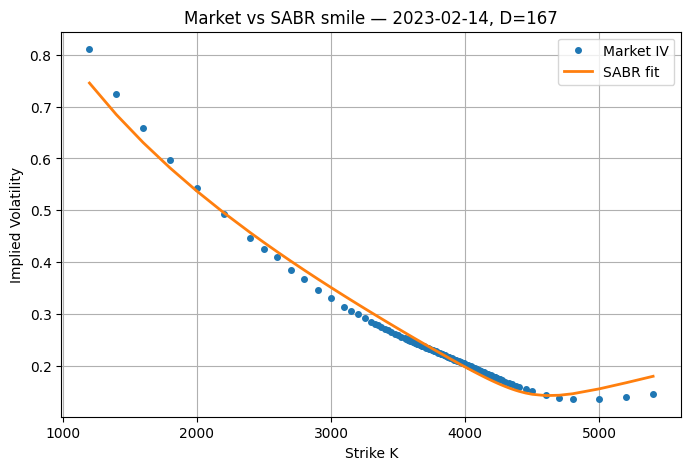

In [ ]:
sample = calib_df.iloc[len(calib_df)//2] 
dt_plot = sample["date"]
D_plot = sample["D_days"]

mask = (df_calib["date"] == dt_plot) & (df_calib["D_days"] == D_plot)
plot_data = df_calib[mask].sort_values("strike")

F_plot = plot_data["F"].iloc[0]
tau_plot = plot_data["tau"].iloc[0]
K_grid = plot_data["strike"].values

sabr_vols = sabr_implied_vol_vec(F_plot, K_grid, tau_plot,sample["alpha"], sample["rho"], sample["nu"])

plt.figure(figsize=(8, 5))
plt.plot(K_grid, plot_data["impl_volatility"].values, 'o', label="Market", markersize=4)
plt.plot(K_grid, sabr_vols, '-', label="SABR fit", linewidth=2)
plt.title(f"Market vs SABR smile — {dt_plot.date()}, D={int(D_plot)}")
plt.xlabel("Strike K")
plt.ylabel("Implied Volatility")
plt.legend()
plt.grid(True)
plt.show()





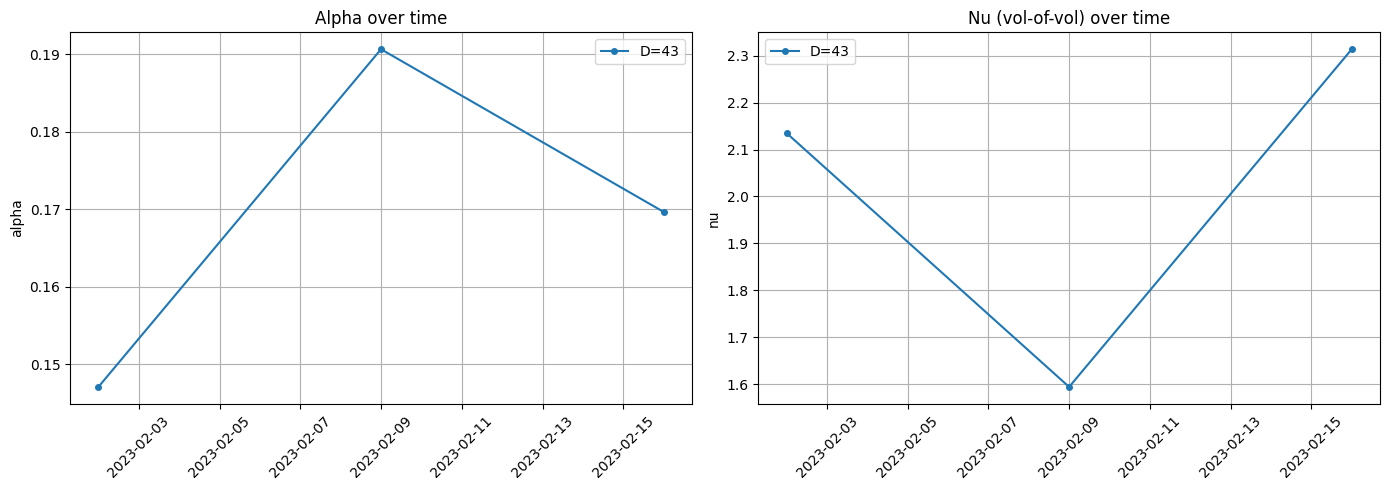

In [31]:
D_values = sorted(calib_df["D_days"].unique())
D_short = D_values[len(D_values)//4]   
D_long = D_values[3*len(D_values)//4] 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for D_sel, label in [(D_short, f"D={D_short}"), (D_long, f"D={D_long}")]:
    sub = calib_df[calib_df["D_days"] == D_sel].sort_values("date")
    if len(sub) < 2:
        continue
    axes[0].plot(sub["date"], sub["alpha"], marker='o', label=label, markersize=4)
    axes[1].plot(sub["date"], sub["nu"], marker='o', label=label, markersize=4)

axes[0].set_title("Alpha over time")
axes[0].set_ylabel("alpha")
axes[0].legend()
axes[0].grid(True)
axes[0].tick_params(axis='x', rotation=45)

axes[1].set_title("Nu (vol-of-vol) over time")
axes[1].set_ylabel("nu")
axes[1].legend()
axes[1].grid(True)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [32]:
print(f"Calibration RMSE summary across all slices:{calib_df['vol_rmse'].describe()}")

Calibration RMSE summary across all slices:count    609.000000
mean       0.035436
std        0.063517
min        0.001431
25%        0.008385
50%        0.013036
75%        0.024866
max        0.415289
Name: vol_rmse, dtype: float64


In [39]:
#Step 6
cols_sabr = ["alpha", "rho", "nu"]
df = df.drop(columns=[c for c in cols_sabr if c in df.columns])
df = df.merge(calib_df[["date", "D_days", "alpha", "rho", "nu"]],on=["date", "D_days"],how="left")
print(f"Rows with SABR params: {df['alpha'].notna().sum()} / {len(df)}")

Rows with SABR params: 116891 / 141619
